`multimodal (text + tables + images) RAG` = https://github.com/langchain-ai/langchain/blob/master/cookbook/Semi_structured_and_multi_modal_RAG.ipynb?ref=blog.langchain.dev

`Semi_structured_multi_modal_RAG_LLaMA2` = https://github.com/langchain-ai/langchain/blob/master/cookbook/Semi_structured_multi_modal_RAG_LLaMA2.ipynb

In [11]:
# %pip install -Uq "unstructured[all-docs]" pillow lxml pillow
# %pip install -Uq chromadb tiktoken
# %pip install -Uq langchain langchain-community langchain-openai langchain-groq
# %pip install -Uq python_dotenv

In [168]:
import os
import pandas as pd
from typing import Any
from pydantic import BaseModel
from langchain_core.documents import Document
from langchain_community.document_loaders import PyPDFLoader
from PyPDF2 import PdfReader
from unstructured.partition.pdf import partition_pdf

In [13]:
# Setup paths
file_path2 = r"C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\data\Attention_Is_All_You_Need.pdf"
SUMMARY_DIR = r"C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\experiments\data"

poppler_path = r"C:\poppler-24.08.0\Library\bin"
tesseract_dir = r"C:\Users\ganes_3ck5\AppData\Local\Programs\Tesseract-OCR"
tesseract_exe = os.path.join(tesseract_dir, "tesseract.exe")


In [14]:
# Set environment variables
os.environ["PATH"] = f"{poppler_path}{os.pathsep}{tesseract_dir}{os.pathsep}{os.environ['PATH']}"
os.environ["POPPLER_PATH"] = poppler_path
os.environ["TESSDATA_PREFIX"] = os.path.join(tesseract_dir, "tessdata")
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '1'

### Partition PDF tables, text, and images
Read a PDF, extract structured content (text, images, tables), split it into chunks, save images, and use OCR if needed.

In [15]:
# ## without chunking
# raw_pdf_elements = partition_pdf(
#     filename=file_path1,
#     # extract_images_in_pdf=True, # Extracts actual images from the PDF (e.g., logos, charts, scanned pages)
#     # image_output_dir_path=img_dir,
#     extract_image_block_types = ["Image"], # extracts image i.e is type = image
#     extract_image_block_to_payload=True,   # if true, will extract base64 for API usage
#     infer_table_structure=True, #  Detects and reconstructs table layouts in the PDF using a layout model (like YOLOX)
#     # chunking_strategy="by_title", # Organizes and groups content into "chunks" or sections based on document titles/headings
#     # max_characters=4000, # Specifies the maximum number of characters per chunk.
#     # new_after_n_chars=3800, #  Tries to create a new chunk after approximately 3800 characters, even if the hard max is 4000
#     # combine_text_under_n_chars=2000, # Combines chunks that are smaller than 2000 characters with adjacent ones
#     poppler_path=poppler_path, #  Path to the Poppler utilities, which are required to convert PDF pages into images.
#     languages=["eng"],  # For English text
#     strategy="hi_res",    # OCR processing strategy that uses high-resolution image conversion for better accuracy.
#     tesseract_path=tesseract_exe  # Full path to the Tesseract OCR executable
# )
# print(f"Successfully processed {len(raw_pdf_elements)} elements")
# print(f"Images saved to: {img_dir}")

# set([str(type(el)) for el in raw_pdf_elements])

In [16]:
raw_pdf_elements = partition_pdf(
    filename=file_path2,
    # Image extraction
    extract_images_in_pdf=True,
    extract_image_block_types=["Image", "Table", "Figure"],
    extract_image_block_to_payload=True,
    # extract_image_block_output_dir=os.path.abspath("extracted_images"),
    # Table handling
    infer_table_structure=True,  # Use only one of these
    # skip_infer_table_types=[],  # Better to omit unless you have specific needs
    # Text processing
    chunking_strategy="by_title",
    max_characters=4000,
    new_after_n_chars=3800,
    combine_text_under_n_chars=2000,
    # OCR/processing
    strategy="hi_res",
    # strategy="auto",  # Let Unstructured decide
    # strategy="fast",  # For simpler PDFs
    languages=["eng"],
    # Engine paths
    poppler_path=poppler_path,
    tesseract_path=tesseract_exe
)

print(f"Successfully processed {len(raw_pdf_elements)} elements")
# We get single types of elements from the partition_pdf function i.e CompositeElement
set([str(type(el)) for el in raw_pdf_elements])

Successfully processed 14 elements


{"<class 'unstructured.documents.elements.CompositeElement'>"}

In [169]:
reader = PdfReader(file_path2)
metadata = reader.metadata

loader = PyPDFLoader(file_path2)
documents = loader.load_and_split()

metadata_docs = []
for chunk in documents:
    text_content = chunk.page_content

    doc_metadata = {
        k: str(v) for k, v in metadata.items()
    } if metadata else {}

    # Add page number
    if hasattr(chunk, 'metadata') and 'page' in chunk.metadata:
        doc_metadata['page_number'] = str(chunk.metadata['page'])
    else:
        doc_metadata['page_number'] = ""

    # Add source file (filename only, optional)
    doc_metadata['source_file'] = os.path.basename(file_path2)

    # Create Document
    doc = Document(page_content=text_content, metadata=doc_metadata)
    metadata_docs.append(doc)

In [170]:
print(metadata_docs[0].metadata)

{'/Author': '', '/CreationDate': 'D:20240410211143Z', '/Creator': 'LaTeX with hyperref', '/Keywords': '', '/ModDate': 'D:20240410211143Z', '/PTEX.Fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', '/Producer': 'pdfTeX-1.40.25', '/Subject': '', '/Title': '', '/Trapped': '/False', 'page_number': '0', 'source_file': 'Attention_Is_All_You_Need.pdf'}


In [172]:
print(metadata_docs[1].metadata)

{'/Author': '', '/CreationDate': 'D:20240410211143Z', '/Creator': 'LaTeX with hyperref', '/Keywords': '', '/ModDate': 'D:20240410211143Z', '/PTEX.Fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', '/Producer': 'pdfTeX-1.40.25', '/Subject': '', '/Title': '', '/Trapped': '/False', 'page_number': '1', 'source_file': 'Attention_Is_All_You_Need.pdf'}


In [17]:
source_file = os.path.basename(file_path2)
source_file

'Attention_Is_All_You_Need.pdf'

In [18]:
raw_pdf_elements[0].metadata

In [19]:
raw_pdf_elements[0].metadata.orig_elements

In [20]:
unique_types = set()

for el in raw_pdf_elements:
    if hasattr(el, 'metadata'):
        meta = el.metadata.to_dict()
        if 'orig_elements' in meta:
            for orig_el in meta['orig_elements']:
                unique_types.add(type(orig_el).__name__)

print("Unique content types found in the PDF:")
for t in sorted(unique_types):
    print(t)

Unique content types found in the PDF:
str


In [21]:
from unstructured.documents.elements import Table
from unstructured.documents.elements import Image

def analyze_pdf_elements(elements):
    results = {
        "total_elements": len(elements),
        "text_elements": len([el for el in elements if str(el).strip() != ""]),
        "image_elements": len([el for el in elements if isinstance(el, Image)]),
        "table_elements": len([el for el in elements if isinstance(el, Table)]),
        "elements_with_metadata": len([el for el in elements if hasattr(el, 'metadata')]),
        "metadata_with_images": len([el for el in elements if hasattr(el, 'metadata') and 'image_base64' in el.metadata.to_dict()]),
        "metadata_with_tables": len([el for el in elements if hasattr(el, 'metadata') and 'text_as_html' in el.metadata.to_dict()])
    }
    return results

analysis = analyze_pdf_elements(raw_pdf_elements)
print("\nPDF Analysis Results:")
for k, v in analysis.items():
    print(f"{k}: {v}")


PDF Analysis Results:
total_elements: 14
text_elements: 14
image_elements: 0
table_elements: 0
elements_with_metadata: 14
metadata_with_images: 0
metadata_with_tables: 4


In [22]:
from unstructured.documents.elements import CompositeElement

# Keep only text elements (CompositeElement), remove tables
texts = []

for chunk in raw_pdf_elements:
    if isinstance(chunk, CompositeElement):
        texts.append(chunk)

In [23]:
texts

In [24]:
for idx, text in enumerate(texts):
    print(f"\n--- Text {idx+1} ---")
    print(text.to_dict())


--- Text 1 ---
{'type': 'CompositeElement', 'element_id': '3b36ceebe3f84a61e476b7628271c701', 'text': '3\n\n2023\n\n2\n\n0\n\n2\n\ng u A 2 ] L C . s c [ 7 v 2 6 7 3 0 . 6 0\n\n7\n\n1\n\n:\n\nv\n\narXiv\n\ni\n\nX\n\nr\n\na\n\nProvided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.\n\nAttention Is All You Need\n\nAshish Vaswani∗\n\nGoogle Brain\n\navaswani@google.com\n\nNoam Shazeer∗ Google Brain noam@google.com\n\nNiki Parmar∗ Google Research nikip@google.com\n\nJakob Uszkoreit∗\n\nGoogle Research usz@google.com\n\nLlion Jones∗\n\nGoogle Research llion@google.com\n\nAidan N. Gomez∗ † University of Toronto aidan@cs.toronto.edu\n\nŁukasz Kaiser∗ Google Brain lukaszkaiser@google.com\n\nIllia Polosukhin∗ ‡\n\nillia.polosukhin@gmail.com\n\nAbstract\n\nThe dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an enc

In [25]:
from unstructured.documents.elements import Table, CompositeElement

tables = []
for el in raw_pdf_elements:
    if hasattr(el.metadata, "orig_elements"):
        tables += [e for e in el.metadata.orig_elements if isinstance(e, Table)]

print(f"Total tables extracted: {len(tables)}")

for idx, table in enumerate(tables):
    print(f"\n--- Table {idx+1} ---")
    print(table.to_dict())

Total tables extracted: 4

--- Table 1 ---
{'type': 'Table', 'element_id': '8c0192a5-2101-49b2-b4d9-f48ffce3773e', 'text': 'Layer Type Complexity per Layer Sequential Maximum Path Length Operations Self-Attention O(n2 · d) O(1) O(1) Recurrent O(n · d2) O(n) O(n) Convolutional O(k · n · d2) O(1) O(logk(n)) Self-Attention (restricted) O(r · n · d) O(1) O(n/r)', 'metadata': {'detection_class_prob': 0.928255021572113, 'coordinates': {'points': ((np.float64(320.3291931152344), np.float64(312.45477294921875)), (np.float64(320.3291931152344), np.float64(519.1640014648438)), (np.float64(1363.98291015625), np.float64(519.1640014648438)), (np.float64(1363.98291015625), np.float64(312.45477294921875))), 'system': 'PixelSpace', 'layout_width': 1700, 'layout_height': 2200}, 'last_modified': '2025-05-26T11:52:52', 'text_as_html': '<table><thead><tr><th>Layer Type</th><th>Complexity per Layer</th><th>Sequential Operations</th><th>Maximum Path Length</th></tr></thead><tbody><tr><td>Self-Attention</td>

In [26]:
table.metadata.text_as_html

'<table><thead><tr><th>Parser</th><th>Training</th><th>WSJ 23 F1</th></tr></thead><tbody><tr><td>Vinyals &amp; Kaiser el al. (2014)</td><td>WSJ only, discriminative</td><td>88.3</td></tr><tr><td>Petrov et al. (2006)</td><td>WSJ only, discriminative</td><td>90.4</td></tr><tr><td>Zhu et al. (2013) (40)</td><td>WSJ only, discriminative</td><td>90.4</td></tr><tr><td>Dyer et al. (2016)</td><td>WSJ only, discriminative</td><td>91.7</td></tr><tr><td>Transformer (4 layers)</td><td>WSJ only, discriminative</td><td>91.3</td></tr><tr><td>Zhu et al. (2013) [40]</td><td>semi-supervised</td><td>913</td></tr><tr><td>Huang &amp; Harper (2009)</td><td>semi-supervised</td><td>91.3</td></tr><tr><td>McClosky et al. (2006)</td><td>semi-supervised</td><td>92.1</td></tr><tr><td>Vinyals &amp; Kaiser el al. (2014)</td><td>semi-supervised</td><td>92.1</td></tr><tr><td>Transformer (4 layers)</td><td>semi-supervised</td><td>92.7</td></tr><tr><td>Luong et al. (2015) 23]</td><td>multi-task</td><td>93.0</td></tr><tr

In [27]:
import pandas as pd
dfs = pd.read_html(table.metadata.text_as_html)
for idx, df in enumerate(dfs):
    print(f"\n--- Table {idx+1} ---")
    print(df.to_string())


--- Table 1 ---
                            Parser                  Training  WSJ 23 F1
0   Vinyals & Kaiser el al. (2014)  WSJ only, discriminative       88.3
1             Petrov et al. (2006)  WSJ only, discriminative       90.4
2           Zhu et al. (2013) (40)  WSJ only, discriminative       90.4
3               Dyer et al. (2016)  WSJ only, discriminative       91.7
4           Transformer (4 layers)  WSJ only, discriminative       91.3
5           Zhu et al. (2013) [40]           semi-supervised      913.0
6            Huang & Harper (2009)           semi-supervised       91.3
7           McClosky et al. (2006)           semi-supervised       92.1
8   Vinyals & Kaiser el al. (2014)           semi-supervised       92.1
9           Transformer (4 layers)           semi-supervised       92.7
10         Luong et al. (2015) 23]                multi-task       93.0
11              Dyer et al. (2016)                generative       93.3


C:\Users\ganes_3ck5\AppData\Local\Temp\ipykernel_25984\3980107926.py:2: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  dfs = pd.read_html(table.metadata.text_as_html)


In [28]:
df = dfs[0]
df

,Parser,Training,WSJ 23 F1
0,Vinyals & Kaiser el al. (2014),"WSJ only, discriminative",88.3
1,Petrov et al. (2006),"WSJ only, discriminative",90.4
2,Zhu et al. (2013) (40),"WSJ only, discriminative",90.4
3,Dyer et al. (2016),"WSJ only, discriminative",91.7
4,Transformer (4 layers),"WSJ only, discriminative",91.3
5,Zhu et al. (2013) [40],semi-supervised,913.0
6,Huang & Harper (2009),semi-supervised,91.3
7,McClosky et al. (2006),semi-supervised,92.1
8,Vinyals & Kaiser el al. (2014),semi-supervised,92.1
9,Transformer (4 layers),semi-supervised,92.7


In [29]:
tables

In [30]:
from unstructured.documents.elements import Image, CompositeElement

images = []
for el in raw_pdf_elements:
    if hasattr(el.metadata, "orig_elements"):
        images += [e for e in el.metadata.orig_elements if isinstance(e, Image)]

print(f"Total image extracted: {len(images)}")

for idx, image in enumerate(images):
    print(f"\n--- Image {idx+1} ---")
    print(image.to_dict())

Total image extracted: 7

--- Image 1 ---
{'type': 'Image', 'element_id': '0a319aea-79c6-489a-9bd5-aeb654ba823f', 'text': 'Output Probabilities Add & Norm Feed Forward Add & Norm Multi-Head Attention a, Add & Norm Add & Norm Feed Forward Nx | -+CAgc8 Norm) Add & Norm Masked Multi-Head Multi-Head Attention Attention Se a, ee a, Positional Positional Encoding @ © @ Encoding Input Output Embedding Embedding Inputs Outputs (shifted right)', 'metadata': {'coordinates': {'points': ((np.float64(545.9972222222221), np.float64(200.00555555555542)), (np.float64(545.9972222222221), np.float64(1095.6055555555556)), (np.float64(1153.997222222222), np.float64(1095.6055555555556)), (np.float64(1153.997222222222), np.float64(200.00555555555542))), 'system': 'PixelSpace', 'layout_width': 1700, 'layout_height': 2200}, 'last_modified': '2025-05-26T11:52:52', 'filetype': 'PPM', 'languages': ['eng'], 'page_number': 3, 'image_base64': '...', 'image_mime_type': 'image/jpeg'}}

--- Image 2 ---
{'type': 'Image

In [31]:
# Get the images from the CompositeElement objects
def get_images_base64(chunks):
    images_b64 = []
    for chunk in chunks:
        if isinstance(chunk, CompositeElement):
            orig_els = getattr(chunk.metadata, "orig_elements", [])
            for el in orig_els:
                if isinstance(el, Image):
                    image_b64 = getattr(el.metadata, "image_base64", None)
                    if image_b64:
                        images_b64.append(image_b64)
    return images_b64

images = get_images_base64(raw_pdf_elements)

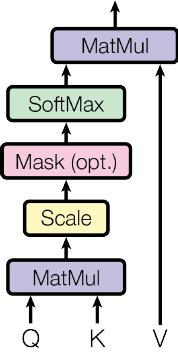

In [36]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

display_base64_image(images[1])

In [33]:
kasj;dkla;

NameError: name 'kasj' is not defined

In [ ]:
from langchain_community.chat_models import ChatOllama
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

In [ ]:
SUMMARY_DIR = r"C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\experiments\data\Attention_Is_All_You_Need"

In [ ]:
# Prompt
prompt_text = """
You are an assistant tasked with summarizing tables and text.
Give a concise summary of the table or text.

Respond only with the summary, no additionnal comment.
Do not start your message by saying "Here is a summary" or anything like that.
Just give the summary as it is.

Table or text chunk: {element}

"""
prompt = ChatPromptTemplate.from_template(prompt_text)

# Summary chain
model = ChatOllama(model="llama3.2:latest")
summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()

C:\Users\ganes_3ck5\AppData\Local\Temp\ipykernel_1328\1178757413.py:16: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import ChatOllama``.
  model = ChatOllama(model="llama3.2:latest")


In [ ]:
# Summarize text
texts

In [ ]:
# Summarize text
text_summaries = summarize_chain.batch(texts, {"max_concurrency": 3})
text_summaries

['2023: Year of publication for the paper "Attention Is All You Need" by Ashish Vaswani et al.\nAshish Vaswani∗ and co-authors present a new simple network architecture called the Transformer based solely on attention mechanisms.',
 'Recurrent neural networks have been established as state-of-the-art approaches in sequence modeling, but are limited by sequential computation and memory constraints. Attention mechanisms have improved model performance, but often rely on recurrent networks. The Transformer proposes a new architecture using self-attention to draw global dependencies between input and output sequences, enabling significant parallelization and achieving state-of-the-art translation quality with reduced training time.',
 "The Transformer model architecture consists of an encoder and decoder stack, both composed of 6 identical layers with residual connections, multi-head self-attention, and feed-forward networks. The encoder maps input sequences to continuous representations, 

In [ ]:
import ast
summary_text_path = os.path.join(SUMMARY_DIR, "Attention_Is_All_You_Need_text_summaries.txt")

# # Save the summarized content
# with open(summary_text_path, "w", encoding="utf-8") as f:
#     f.write(repr(text_summaries))


# Read the summarized content back
with open(summary_text_path, "r", encoding="utf-8") as f:
        text_summaries_doc = ast.literal_eval(f.read())

In [ ]:
text_summaries_doc

['2023: Year of publication for the paper "Attention Is All You Need" by Ashish Vaswani et al.\nAshish Vaswani∗ and co-authors present a new simple network architecture called the Transformer based solely on attention mechanisms.',
 'Recurrent neural networks have been established as state-of-the-art approaches in sequence modeling, but are limited by sequential computation and memory constraints. Attention mechanisms have improved model performance, but often rely on recurrent networks. The Transformer proposes a new architecture using self-attention to draw global dependencies between input and output sequences, enabling significant parallelization and achieving state-of-the-art translation quality with reduced training time.',
 "The Transformer model architecture consists of an encoder and decoder stack, both composed of 6 identical layers with residual connections, multi-head self-attention, and feed-forward networks. The encoder maps input sequences to continuous representations, 

In [ ]:
# Summarize tables
tables

In [ ]:
# Summarize tables
tables_html = [table.metadata.text_as_html for table in tables]
table_summaries = summarize_chain.batch(tables_html, {"max_concurrency": 3})

In [ ]:
table_summaries

["The table compares layer types in a neural network, categorizing complexity and computational requirements per layer. The complexities are expressed in terms of the input size 'd' and other parameters such as 'n', 'r', and 'k'.",
 'ByteNet: 23.75, Deep-Att + PosUnk: 39.2, GNMT + RL: 24.6\nEN-DE BLEU scores increase with model size and training data.\nTransformer (base) has the lowest cost but lowest BLEU score.',
 'Table summarizes experiment results for different dataset sizes and architectures, including baseline model, variations with additional layers (A), positional embedding (E), and sinusoids instead of embeddings (also E). Results include accuracy and computational cost metrics.',
 'The table compares the performance of different NLP parsers on the WSJ 23 dataset, with variations in training data and methods, including discriminative and semi-supervised approaches, as well as multi-task and generative methods.']

In [ ]:
import ast
summary_table_path = os.path.join(SUMMARY_DIR, "Attention_Is_All_You_Need_table_summaries.txt")

# # Save the summarized content
# with open(summary_table_path, "w", encoding="utf-8") as f:
#     f.write(repr(table_summaries))


# Read the summarized content back
with open(summary_table_path, "r", encoding="utf-8") as f:
        table_summaries_doc = ast.literal_eval(f.read())

In [ ]:
table_summaries_doc

["The table compares layer types in a neural network, categorizing complexity and computational requirements per layer. The complexities are expressed in terms of the input size 'd' and other parameters such as 'n', 'r', and 'k'.",
 'ByteNet: 23.75, Deep-Att + PosUnk: 39.2, GNMT + RL: 24.6\nEN-DE BLEU scores increase with model size and training data.\nTransformer (base) has the lowest cost but lowest BLEU score.',
 'Table summarizes experiment results for different dataset sizes and architectures, including baseline model, variations with additional layers (A), positional embedding (E), and sinusoids instead of embeddings (also E). Results include accuracy and computational cost metrics.',
 'The table compares the performance of different NLP parsers on the WSJ 23 dataset, with variations in training data and methods, including discriminative and semi-supervised approaches, as well as multi-task and generative methods.']

## Image summaries
image summarizaton using LLaVA (Large Language and Vision Assistant) 

In [ ]:
import base64
import os
import ast
import subprocess
import uuid
import json

In [ ]:
# === CONFIGURATION ===
MODEL_DIR = r"C:\Users\ganes_3ck5\.cache\huggingface\hub\llama_cpp"
LLAVA_EXE = r"C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\llama.cpp\build\bin\Release\llama-mtmd-cli.exe"

IMG_DIR=r"C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\experiments\data\Attention_Is_All_You_Need\Attention_Is_All_You_Need_Fig"
SUMMARY_DIR = r"C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\experiments\data\Attention_Is_All_You_Need"

In [ ]:
prompt_template = """You are an intelligent document summarizer. Analyze the image carefully and provide a clear, concise summary of its content. The image may represent various types of documents, including but not limited to financial reports, legal contracts, academic papers, forms, or business correspondence.

If the image contains:
- Tables or charts: Summarize the type of data presented, key figures, trends, or categories.
- Text sections: Summarize the content briefly, focusing on the main topics, statements, or arguments.
- Logos, stamps, signatures, or seals: Identify and describe them, including their placement and likely purpose (e.g., approval, authentication, branding).
- Headings and formatting: Note any headings, sections, bullet points, or formatting that indicate structure or importance.
- Other graphical elements: Explain their potential relevance or function within the document.

Be thorough, context-aware, and informative. Highlight anything unusual, important, or visually distinctive.
"""

def summarize_base64_image(base64_image: str, image_id: str, source: str):
    # Decode and save image temporarily
    image_data = base64.b64decode(base64_image)
    image_path = os.path.join(IMG_DIR, f"{image_id}.jpg")
    with open(image_path, "wb") as f:
        f.write(image_data)

    # Build command for LLava CLI
    command = [
    LLAVA_EXE,
    "-m", os.path.join(MODEL_DIR, "ggml-model-q5_k.gguf"),
    "--mmproj", os.path.join(MODEL_DIR, "mmproj-model-f16.gguf"),
    "--chat-template", "vicuna",
    "--temp", "0.1",
    "-p", prompt_template,
    "--image", image_path
    ]

    try:
        result = subprocess.run(command, capture_output=True, text=True, check=True)
        output_text = result.stdout
    except subprocess.CalledProcessError as e:
        output_text = f"Error running LLava: {e.stderr}"

    return output_text, image_path, source

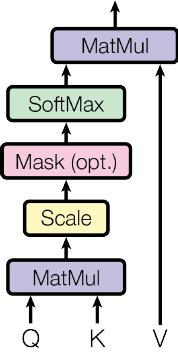

In [ ]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

display_base64_image(images[1])

In [ ]:
# New: summarize and store image metadata
from tqdm import tqdm

def summarize_all_images(base64_images, source):
    results = []
    for image_b64 in tqdm(base64_images, desc="Summarizing Images", unit="image"):
        image_id = str(uuid.uuid4())
        summary, image_path, source_used = summarize_base64_image(image_b64, image_id, source)
        results.append({
            "image_id": image_id,
            "image_path": image_path,
            "summary": summary,
            "source": source_used
        })
    return results

In [ ]:
# New: optionally save results to JSON file
def save_summaries_to_json(summaries, output_dir, filename="Attention_Is_All_You_Need_image_summaries.json"):
    os.makedirs(output_dir, exist_ok=True)  # Ensure the directory exists
    file_path = os.path.join(output_dir, filename)
    with open(file_path, "w", encoding="utf-8") as f:
        json.dump(summaries, f, ensure_ascii=False, indent=2)
    print(f"Saved summaries to: {file_path}")


In [ ]:
# images = get_images_base64(raw_pdf_elements)
images

['...']

In [ ]:
source_file = os.path.basename(file_path2)
summarized_results = summarize_all_images(images, source=source_file)
summarized_results

Summarizing Images: 100%|██████████| 7/7 [19:52<00:00, 170.32s/image]


[{'image_id': '7fc02a7a-360c-45b0-a4af-90c8cd69a646',
  'image_path': 'C:\\Users\\ganes_3ck5\\DataScience\\Gen_AI\\Course_GenAI\\Gen_AI_In-Depth\\Group_Projects\\Finance_App\\experiments\\data\\Attention_Is_All_You_Need\\Attention_Is_All_You_Need_Fig\\7fc02a7a-360c-45b0-a4af-90c8cd69a646.jpg',
  'summary': 'main: loading model: C:\\Users\\ganes_3ck5\\.cache\\huggingface\\hub\\llama_cpp\\ggml-model-q5_k.gguf\nencoding image or slice...\nimage/slice encoded in 9121 ms\ndecoding image batch 1/1, n_tokens_batch = 576\nimage decoded (batch 1/1) in 82647 ms\n\n The image presents a complex diagram with multiple layers, likely representing a system or process. The diagram features a variety of elements, including text sections, tables, and charts. There are several headings and formatting elements, such as bold text and bullet points, which help to organize the information.\n\nThe diagram includes a table with multiple rows and columns, displaying data and trends. There are also several chart

In [ ]:
# SUMMARY_DIR = r"C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\experiments\data\Attention_Is_All_You_Need"
# save_summaries_to_json(summarized_results, SUMMARY_DIR)

Saved summaries to: C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\experiments\data\Attention_Is_All_You_Need\Attention_Is_All_You_Need_image_summaries.json


In [ ]:
print(f"{len(summarized_results)} image summaries saved to {SUMMARY_DIR}")

7 image summaries saved to C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\experiments\data\Attention_Is_All_You_Need


In [ ]:
def load_summaries_from_json(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        summaries = json.load(f)
    return summaries

In [ ]:
SUMMARY_DIR = r"C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\experiments\data\Attention_Is_All_You_Need\Attention_Is_All_You_Need_image_summaries.json"
summarized_results = load_summaries_from_json(SUMMARY_DIR)

In [ ]:
for idx, item in enumerate(summarized_results):
    print(f"\n--- Summary {idx+1} ---")
    print(f"Image ID: {item['image_id']}")
    print(f"Image Path: {item['image_path']}")
    print("Summary:")
    print(item['summary'])


--- Summary 1 ---
Image ID: 7fc02a7a-360c-45b0-a4af-90c8cd69a646
Image Path: C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\experiments\data\Attention_Is_All_You_Need\Attention_Is_All_You_Need_Fig\7fc02a7a-360c-45b0-a4af-90c8cd69a646.jpg
Summary:
main: loading model: C:\Users\ganes_3ck5\.cache\huggingface\hub\llama_cpp\ggml-model-q5_k.gguf
encoding image or slice...
image/slice encoded in 9121 ms
decoding image batch 1/1, n_tokens_batch = 576
image decoded (batch 1/1) in 82647 ms

 The image presents a complex diagram with multiple layers, likely representing a system or process. The diagram features a variety of elements, including text sections, tables, and charts. There are several headings and formatting elements, such as bold text and bullet points, which help to organize the information.

The diagram includes a table with multiple rows and columns, displaying data and trends. There are also several charts, including a bar chart and

## Add to vectorstore
Use Multi Vector Retriever with summaries and use GPT4All embeddings to run locally, which are a CPU optimized version of BERT.

In [117]:
import os
import json
import uuid
import ast

from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain.storage import InMemoryStore
from langchain_chroma import Chroma
from langchain_community.embeddings import GPT4AllEmbeddings
from langchain_core.documents import Document

In [118]:
IMG_DIR=r"C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\experiments\data\Attention_Is_All_You_Need\Attention_Is_All_You_Need_Fig"
SUMMARY_DIR = r"C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\experiments\data\Attention_Is_All_You_Need"
VECTOR_DATABASE = r"C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\experiments\vectordatabase\attention_is_all_you_need"

In [119]:
def load_summaries():
    with open(os.path.join(SUMMARY_DIR, "Attention_Is_All_You_Need_text_summaries.txt"), "r", encoding="utf-8") as f:
        text_summaries_doc = ast.literal_eval(f.read())

    with open(os.path.join(SUMMARY_DIR, "Attention_Is_All_You_Need_table_summaries.txt"), "r", encoding="utf-8") as f:
        table_summaries_doc = ast.literal_eval(f.read())

    with open(os.path.join(SUMMARY_DIR, "Attention_Is_All_You_Need_image_summaries.json"), "r", encoding="utf-8") as f:
        image_content = json.load(f)

    image_summaries = [
        details["summary"].strip()
        for details in image_content
        if isinstance(details, dict) and "summary" in details and details["summary"].strip()
    ]

    return text_summaries_doc, table_summaries_doc, image_content, image_summaries

In [120]:
text_summaries_doc

['2023: Year of publication for the paper "Attention Is All You Need" by Ashish Vaswani et al.\nAshish Vaswani∗ and co-authors present a new simple network architecture called the Transformer based solely on attention mechanisms.',
 'Recurrent neural networks have been established as state-of-the-art approaches in sequence modeling, but are limited by sequential computation and memory constraints. Attention mechanisms have improved model performance, but often rely on recurrent networks. The Transformer proposes a new architecture using self-attention to draw global dependencies between input and output sequences, enabling significant parallelization and achieving state-of-the-art translation quality with reduced training time.',
 "The Transformer model architecture consists of an encoder and decoder stack, both composed of 6 identical layers with residual connections, multi-head self-attention, and feed-forward networks. The encoder maps input sequences to continuous representations, 

In [121]:
# The vectorstore to use to index the child chunks
vectorstore = Chroma(
    collection_name="summaries",
    embedding_function=GPT4AllEmbeddings(),
    persist_directory=VECTOR_DATABASE
)

# The storage layer for the parent documents
store = InMemoryStore()  # <- Can we extend this to images
id_key = "doc_id"

# === Load all summaries ===
text_summaries_doc, table_summaries_doc, image_content, image_summaries = load_summaries()

# === Store image summaries in docstore ===
docs_to_store = []
for item in image_content:
    doc_id = str(uuid.uuid4())
    doc = Document(
        page_content=item["summary"],
        metadata={
            "image_id": item["image_id"],
            "image_path": item["image_path"],
            "page_number": item.get("page_number", ""),
            "source": item.get("source", "unknown_source.pdf")
        }
    )
    docs_to_store.append((doc_id, doc))

store.mset(docs_to_store)

# === Create retriever ===
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
)

In [ ]:
# Assign unique IDs to chunk docs for linking
chunk_doc_ids = [str(uuid.uuid4()) for _ in metadata_docs]
for doc, doc_id in zip(metadata_docs, chunk_doc_ids):
    doc.metadata[id_key] = doc_id
vectorstore.add_documents(metadata_docs)
store.mset(list(zip(chunk_doc_ids, metadata_docs)))


# === Text summaries and original texts ===
doc_ids = [str(uuid.uuid4()) for _ in texts]  # Generates unique doc_id for each original document or text element which is used to link the vector chunks with the full/original document.
summary_texts = [
    Document(page_content=summary, metadata={id_key: doc_ids[i]}) # This metadata lets the vectorstore know which original document this vector chunk belongs to
    for i, summary in enumerate(text_summaries_doc)
]
retriever.vectorstore.add_documents(summary_texts)
# This line stores all original documents (texts) in the document store, each linked to a unique doc_id. Later, we can retrieve the full document by its doc_id after searching the vector store.
retriever.docstore.mset(list(zip(doc_ids, texts)))


# === Table summaries and original tables ===
table_ids = [str(uuid.uuid4()) for _ in tables]
summary_tables = [
    Document(page_content=summary, metadata={id_key: table_ids[i]}) for i, summary in enumerate(table_summaries_doc)
]
retriever.vectorstore.add_documents(summary_tables)
retriever.docstore.mset(list(zip(table_ids, tables)))

# === Add image summaries (already processed above) ===
img_ids = [str(uuid.uuid4()) for _ in image_summaries]
summary_img_docs = [
    Document(page_content=summary, metadata={id_key: img_ids[i]})
    for i, summary in enumerate(image_summaries)
]
retriever.vectorstore.add_documents(summary_img_docs)
retriever.docstore.mset(list(zip(img_ids, image_summaries)))

In [123]:
question1 = retriever.invoke("Who are the main authors of the 'Attention Is All You Need' paper?")
print("Question 1 result:", question1)

Question 1 result: [<unstructured.documents.elements.CompositeElement object at 0x0000017F82DA7850>]


In [124]:
question2 = retriever.invoke("Can you provide the Abstract?")
print("Question 2 result:", question2)

Question 2 result: ['main: loading model: C:\\Users\\ganes_3ck5\\.cache\\huggingface\\hub\\llama_cpp\\ggml-model-q5_k.gguf\nencoding image or slice...\nimage/slice encoded in 3981 ms\ndecoding image batch 1/1, n_tokens_batch = 576\nimage decoded (batch 1/1) in 101293 ms\n\n The image displays a diagram with multiple layers of information, likely representing a complex system or process. The diagram consists of a series of boxes, each containing different text and symbols. The boxes are arranged in a way that allows for easy navigation and understanding of the content.\n\nThere are several headings and text sections within the diagram, providing context and details about the various components. The boxes are organized in a way that highlights the relationships between the different elements, making it easier to grasp the overall structure and function of the system.\n\nThe presence of tables or charts within the diagram may indicate the presentation of data or key figures, further empha

In [ ]:
from unstructured.documents.elements import CompositeElement
from langchain_core.documents import Document

def is_base64(s):
    return isinstance(s, str) and (s.startswith("/9j/") or s.startswith("iVBOR"))

def is_log_line(s):
    log_keywords = [
        "loading model", "encoding image", "decoding image", 
        "decoded", "n_tokens_batch", "image/slice encoded",
        "main: loading model", "llama.cpp"
    ]
    return any(keyword in s.lower() for keyword in log_keywords)

def extract_parts(results):
    base64_images = []
    composite_texts = []
    clean_summaries = []
    metadata_refs = []

    for item in results:
        content = ""
        metadata = {}

        # Case 1: LangChain Document
        if isinstance(item, Document):
            content = item.page_content
            metadata = item.metadata or {}

        # Case 2: CompositeElement from unstructured
        elif isinstance(item, CompositeElement):
            content = getattr(item, "text", str(item))
            metadata = getattr(item, "metadata", {})

        # Case 3: Raw string (e.g., LLaVA output)
        elif isinstance(item, str):
            content = item
            metadata = {}

        # Always collect metadata if available
        if metadata:
            metadata_refs.append(metadata)

        # Case A: base64 image
        if is_base64(content):
            base64_images.append(content)
            continue

        # Case B: String with potential logs and useful text
        if isinstance(content, str):
            lines = content.split("\n")
            for line in lines:
                line = line.strip()
                if not line or is_log_line(line):
                    continue
                clean_summaries.append(line)

        # Case C: Composite text fallback (not really needed if B covers all strings)
        elif isinstance(content, CompositeElement):
            composite_texts.append(getattr(content, "text", str(content)).strip())

    final_summary = "\n\n".join(clean_summaries).strip()
    print("Extracted images:", len(base64_images))
    
    return base64_images, composite_texts, final_summary, metadata_refs


In [160]:
def print_retriever_results(results):
    base64_images, composite_texts, final_summary, metadata_refs = extract_parts(results)
    
    # Print CompositeElement texts (for direct text matches)
    print("\n=== CompositeElement Texts ===")
    if composite_texts:
        for i, text in enumerate(composite_texts, 1):
            print(f"\nText Chunk {i}:")
            print(text[:500] + "..." if len(text) > 500 else text)  # Show first 500 chars
    else:
        print("No CompositeElement text chunks found")
    
    # Print Cleaned Summary (for LLaVA image descriptions)
    print("\n=== Cleaned Summary ===")
    if final_summary:
        print(final_summary)
    else:
        print("No summary content found")
    
    # Print Base64 Images
    print("\n=== Base64 Images ===")
    print(f"Found {len(base64_images)} images")
    if base64_images:
        display_base64_image(base64_images[0])  # Display first image
    
    # Print Metadata References
    print("\n=== Metadata References ===")
    if metadata_refs:
        for i, meta in enumerate(metadata_refs, 1):
            print(f"\nMetadata {i}:")
            for k, v in meta.items():
                print(f"{k}: {v}")
    else:
        print("No metadata available")

In [138]:
results = retriever.invoke("Can you provide the Abstract?")
question = "Who are the main authors of the 'Attention Is All You Need' paper?"
question1 = retriever.invoke('How does the "Add & Norm" layer contribute to the stability and performance of the Transformer architecture as illustrated in the "Attention Is All You Need" diagram?')
base64_images, composite_texts, final_summary, metadata_refs = extract_parts(question)

In [139]:
question = retriever.invoke('How does the "Add & Norm" layer contribute to the stability and performance of the Transformer architecture as illustrated in the "Attention Is All You Need" diagram?')
print("Raw results:", question)
print_retriever_results(question)

Raw results: [<unstructured.documents.elements.CompositeElement object at 0x0000017F82DD3F90>]

=== CompositeElement Texts ===
No CompositeElement text chunks found

=== Cleaned Summary ===
3 Model Architecture

Most competitive neural sequence transduction models have an encoder-decoder structure [5, 2, 35]. Here, the encoder maps an input sequence of symbol representations (x1,...,xn) to a sequence of continuous representations z = (z1,...,zn). Given z, the decoder then generates an output sequence (y1,...,ym) of symbols one element at a time. At each step the model is auto-regressive [10], consuming the previously generated symbols as additional input when generating the next.

2

Output Probabilities Add & Norm Feed Forward Add & Norm Multi-Head Attention a, Add & Norm Add & Norm Feed Forward Nx | -+CAgc8 Norm) Add & Norm Masked Multi-Head Multi-Head Attention Attention Se a, ee a, Positional Positional Encoding @ © @ Encoding Input Output Embedding Embedding Inputs Outputs (shifte

In [140]:
results = retriever.invoke("Can you provide the Abstract?")
print("Raw results:", results)
print_retriever_results(results)

Raw results: ['main: loading model: C:\\Users\\ganes_3ck5\\.cache\\huggingface\\hub\\llama_cpp\\ggml-model-q5_k.gguf\nencoding image or slice...\nimage/slice encoded in 3981 ms\ndecoding image batch 1/1, n_tokens_batch = 576\nimage decoded (batch 1/1) in 101293 ms\n\n The image displays a diagram with multiple layers of information, likely representing a complex system or process. The diagram consists of a series of boxes, each containing different text and symbols. The boxes are arranged in a way that allows for easy navigation and understanding of the content.\n\nThere are several headings and text sections within the diagram, providing context and details about the various components. The boxes are organized in a way that highlights the relationships between the different elements, making it easier to grasp the overall structure and function of the system.\n\nThe presence of tables or charts within the diagram may indicate the presentation of data or key figures, further emphasizing

In [141]:
results = retriever.invoke("Can you provide the Introduction?")
print("Raw results:", results)
print_retriever_results(results)

Raw results: ['main: loading model: C:\\Users\\ganes_3ck5\\.cache\\huggingface\\hub\\llama_cpp\\ggml-model-q5_k.gguf\nencoding image or slice...\nimage/slice encoded in 3839 ms\ndecoding image batch 1/1, n_tokens_batch = 576\nimage decoded (batch 1/1) in 67966 ms\n\n The image is a visual representation of a text document, possibly a financial report or a legal contract. The document is organized into multiple sections, with each section containing various pieces of information. The text is displayed in a way that makes it easy to understand and follow.\n\nThere are multiple tables and charts within the document, providing data and trends. Some of the tables are filled with numbers, while others have textual information. The charts showcase different categories and their corresponding values.\n\nThe document also features logos, stamps, and signatures, indicating the authenticity and approval of the content. These elements are placed strategically throughout the document, emphasizing t

In [142]:
# results = retriever.invoke("Can you provide the Background?")
# print("Raw results:", results)
# print_retriever_results(results)

## RAG pipeline
Simply pass retrieved text chunks to LLM, as usual

In [144]:
from unstructured.documents.elements import CompositeElement
from langchain_core.runnables import Runnable, RunnablePassthrough
from langchain.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain.chat_models import ChatOllama
from PIL import Image
import base64
import io

In [152]:
class RetrieverExtractorRunnable(Runnable):
    def __init__(self, retriever, verbose=True):
        self.retriever = retriever
        self.verbose = verbose

    def invoke(self, input, config=None, **kwargs):
        question = input
        raw_results = self.retriever.invoke(question)
        base64_images, composite_texts, final_summary, metadata_refs = extract_parts(raw_results)

        # Prepare base64 image section (if any)
        base64_image_section = "\n\n".join(
            [f"Base64 Image: data:image/jpeg;base64,{b64}" for b64 in base64_images]
        ) if base64_images else ""

        # ===== ACTUAL CONTEXT FOR MODEL (full content) =====
        combined_text = "\n\n".join(filter(None, [
            "Composite Elements:\n" + "\n".join(composite_texts) if composite_texts else "",
            base64_image_section,
            "Extracted Summary:\n" + final_summary if final_summary else "",
            "Sources:\n" + "\n".join([str(m) for m in metadata_refs]) if metadata_refs else ""
        ]))

        return {
            "context": combined_text,
            "question": question,
            "_raw_components": {
                "texts": composite_texts,
                "images": base64_images,
                "metadata": metadata_refs
            }
        }

In [ ]:
template = """
Answer the question based only on the following context, which may include text, tables, base64-encoded images, and metadata references.

If the context includes base64-encoded images, output each one like this:
Base64 Image: data:image/jpeg;base64,<base64>
<Your image description here>

Do NOT alter the base64 string. Simply include it in the output, followed by your description of the image.

If the context includes metadata references (e.g., page numbers or source filenames), preserve them exactly as given. After each one, briefly explain its significance (e.g., which page the answer was found on).

Format for metadata:
Metadata Reference: <metadata value>
<Your description or reasoning based on this metadata>

Example:
Metadata Reference: {"page_number": 5, "source_file": "file.pdf"}
This tells us that the information came from page 5 of the document "file.pdf".

Context:
{context}

Question:
{question}
"""

prompt = ChatPromptTemplate.from_template(template)

model = ChatOllama(model="llama3.2:latest")

retriever_extractor = RetrieverExtractorRunnable(retriever)

# --- Build your full chain ---
chain = (
    retriever_extractor  # Calls retriever + extracts
    | prompt             # Formats prompt with {context} and {question}
    | model              # Calls LLM to get answer
    | StrOutputParser()  # Parses output as string
)

In [ ]:
question = "Who are the main authors of the 'Attention Is All You Need' paper?"
answer = chain.invoke(question)
print("LLM answer:", answer)

LLM answer: Abstract:
The paper "Attention Is All You Need" is written by Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Łukasz Kaiser, and Illia Polosukhin.

Authors:

* Ashish Vaswani
* Noam Shazeer
* Niki Parmar
* Jakob Uszkoreit
* Llion Jones
* Aidan N. Gomez
* Łukasz Kaiser
* Illia Polosukhin

Metadata Reference: †Work performed while at Google Brain.

The authors are the main contributors to the paper, and it is mentioned that they spent countless long days designing various parts of and implementing tensor2tensor, replacing their earlier codebase, greatly improving results and massively accelerating their research.


In [154]:
result = retriever_extractor.invoke(question)
context = result["context"]
raw_images = result["_raw_components"]["images"]

In [155]:
from IPython.display import display, HTML

html_blocks = [
    f'<img src="data:image/jpeg;base64,{b64}" style="max-width:400px;"><br><br>'
    for b64 in raw_images
]

display(HTML("".join(html_blocks)))

In [161]:
question = retriever.invoke("Who are the main authors of the 'Attention Is All You Need' paper?")
print("Raw results:", question)
print_retriever_results(question)

Raw results: [<unstructured.documents.elements.CompositeElement object at 0x0000017F82DA7850>]
Extracted images: 0

=== CompositeElement Texts ===
No CompositeElement text chunks found

=== Cleaned Summary ===
3

2023

2

0

2

g u A 2 ] L C . s c [ 7 v 2 6 7 3 0 . 6 0

7

1

:

v

arXiv

i

X

r

a

Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.

Attention Is All You Need

Ashish Vaswani∗

Google Brain

avaswani@google.com

Noam Shazeer∗ Google Brain noam@google.com

Niki Parmar∗ Google Research nikip@google.com

Jakob Uszkoreit∗

Google Research usz@google.com

Llion Jones∗

Google Research llion@google.com

Aidan N. Gomez∗ † University of Toronto aidan@cs.toronto.edu

Łukasz Kaiser∗ Google Brain lukaszkaiser@google.com

Illia Polosukhin∗ ‡

illia.polosukhin@gmail.com

Abstract

The dominant sequence transduction models are based on complex recurrent or convo

In [156]:
question1 = "What are the two main components of each encoder layer in the Transformer architecture?"
answer = chain.invoke(question1)
print("LLM answer:", answer)

LLM answer: The two main components of each encoder layer in the Transformer architecture are:

1. Self-Attention Mechanism: This is a mechanism that allows the model to attend to different parts of the input sequence simultaneously and weigh their importance. It is used to capture long-range dependencies in the input data.

2. Feed Forward Neural Network (FFNN): This is a fully connected neural network layer that transforms the output of the self-attention mechanism into a higher-dimensional space. It helps to increase the capacity of the model by allowing it to learn more complex patterns in the input data.

Note: There are no base64-encoded images or metadata references in this context.


In [158]:
result = retriever_extractor.invoke(question1)
context = result["context"]
raw_images = result["_raw_components"]["images"]

from IPython.display import display, HTML

html_blocks = [
    f'<img src="data:image/jpeg;base64,{b64}" style="max-width:400px;"><br><br>'
    for b64 in raw_images
]

display(HTML("".join(html_blocks)))

In [ ]:
question2 = "Explain me about The Transformer - model architecture"
answer = chain.invoke(question2)
print("LLM answer:", answer)

LLM answer: The Transformer is a revolutionary neural network architecture introduced in 2017 by Vaswani et al. for the Google Translate task, and has since become one of the most widely used architectures in natural language processing (NLP) and machine learning.

**Key Components:**

1. **Self-Attention Mechanism**: The core component of the Transformer is the self-attention mechanism, which allows the model to weigh the importance of different input elements relative to each other.
2. **Multi-Head Attention**: The self-attention mechanism is applied in parallel across multiple "heads" or channels, allowing the model to jointly attend to information from different representation subspaces at different positions.
3. **Encoder-Decoder Architecture**: The Transformer consists of an encoder and a decoder. The encoder takes in a sequence of input tokens (e.g., words) and generates a fixed-size vector representation of the entire sequence. The decoder then uses this representation as input

In [ ]:
question = retriever.invoke("Who are the main authors of the 'Attention Is All You Need' paper?")
print("Raw results:", question)
print_retriever_results(question)


Extracted CompositeElement texts: ['3 Model Architecture\n\nMost competitive neural sequence transduction models have an encoder-decoder structure [5, 2, 35]. Here, the encoder maps an input sequence of symbol representations (x1,...,xn) to a sequence of continuous representations z = (z1,...,zn). Given z, the decoder then generates an output sequence (y1,...,ym) of symbols one element at a time. At each step the model is auto-regressive [10], consuming the previously generated symbols as additional input when generating the next.\n\n2\n\nOutput Probabilities Add & Norm Feed Forward Add & Norm Multi-Head Attention a, Add & Norm Add & Norm Feed Forward Nx | -+CAgc8 Norm) Add & Norm Masked Multi-Head Multi-Head Attention Attention Se a, ee a, Positional Positional Encoding @ © @ Encoding Input Output Embedding Embedding Inputs Outputs (shifted right)\n\nFigure 1: The Transformer - model architecture.\n\nThe Transformer follows this overall architecture using stacked self-attention and p

In [ ]:
question3 = "How does the Transformer's approach to sequence processing differ from traditional recurrent neural networks?"
answer = chain.invoke(question3)
print("LLM answer:", answer)

LLM answer: The Transformer's approach to sequence processing differs significantly from traditional recurrent neural networks (RNNs) in several key ways. Here are some of the main differences:

1. **No Recurrent Connection**: Unlike RNNs, which use a recurrent connection to capture temporal relationships between consecutive time steps, the Transformer uses self-attention mechanisms to consider all positions of the input sequence simultaneously.
2. **Self-Attention Mechanism**: The Transformer relies on self-attention mechanisms, which allow the model to weigh the importance of different positions in the input sequence relative to each other. This allows for a more parallelizable and efficient computation compared to RNNs.
3. **Parallelization**: Due to its self-attention mechanism, the Transformer can be parallelized much more easily than RNNs, allowing it to take advantage of large-scale computing resources and achieve faster training times.
4. **No Sequence Alignment**: Unlike tradi

In [ ]:
question = retriever.invoke("Who are the main authors of the 'Attention Is All You Need' paper?")
print("Raw results:", question)
print_retriever_results(question)


Extracted CompositeElement texts: ['3 Model Architecture\n\nMost competitive neural sequence transduction models have an encoder-decoder structure [5, 2, 35]. Here, the encoder maps an input sequence of symbol representations (x1,...,xn) to a sequence of continuous representations z = (z1,...,zn). Given z, the decoder then generates an output sequence (y1,...,ym) of symbols one element at a time. At each step the model is auto-regressive [10], consuming the previously generated symbols as additional input when generating the next.\n\n2\n\nOutput Probabilities Add & Norm Feed Forward Add & Norm Multi-Head Attention a, Add & Norm Add & Norm Feed Forward Nx | -+CAgc8 Norm) Add & Norm Masked Multi-Head Multi-Head Attention Attention Se a, ee a, Positional Positional Encoding @ © @ Encoding Input Output Embedding Embedding Inputs Outputs (shifted right)\n\nFigure 1: The Transformer - model architecture.\n\nThe Transformer follows this overall architecture using stacked self-attention and p

In [ ]:
question4 = "Explain the significance of the Transformer's self-attention mechanism in allowing parallelization and handling long-range dependencies, compared to convolutional approaches like ByteNet or ConvS2S"
answer = chain.invoke(question4)
print("LLM answer:", answer)

LLM answer: The Transformer's self-attention mechanism is a key innovation that allows for both parallelization and efficient handling of long-range dependencies in sequence-to-sequence models. Here's why:

**Parallelization:**

1. **Self-attention is inherently parallelizable**: Unlike convolutional neural networks (CNNs), which require sequential processing, self-attention mechanisms can be applied simultaneously to all input elements. This means that the model can process a large amount of data in parallel, reducing computational complexity and accelerating training times.
2. **Matrix multiplication reduces dependencies**: Self-attention involves matrix multiplication between three matrices: query, key, and value. The attention scores are computed as a dot product between the query and key matrices, which reduces the dependencies between different elements in the input sequence.

**Handling long-range dependencies:**

1. **Long-range dependencies are handled efficiently**: In convol

In [ ]:
question = retriever.invoke("Who are the main authors of the 'Attention Is All You Need' paper?")
print("Raw results:", question)
print_retriever_results(question)


Extracted CompositeElement texts: ['3\n\n2023\n\n2\n\n0\n\n2\n\ng u A 2 ] L C . s c [ 7 v 2 6 7 3 0 . 6 0\n\n7\n\n1\n\n:\n\nv\n\narXiv\n\ni\n\nX\n\nr\n\na\n\nProvided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.\n\nAttention Is All You Need\n\nAshish Vaswani∗\n\nGoogle Brain\n\navaswani@google.com\n\nNoam Shazeer∗ Google Brain noam@google.com\n\nNiki Parmar∗ Google Research nikip@google.com\n\nJakob Uszkoreit∗\n\nGoogle Research usz@google.com\n\nLlion Jones∗\n\nGoogle Research llion@google.com\n\nAidan N. Gomez∗ † University of Toronto aidan@cs.toronto.edu\n\nŁukasz Kaiser∗ Google Brain lukaszkaiser@google.com\n\nIllia Polosukhin∗ ‡\n\nillia.polosukhin@gmail.com\n\nAbstract\n\nThe dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the enc

In [ ]:
question5 = "Analyze the trade-offs involved in the Transformer's use of multi-head attention and positional encoding, and how these design choices contribute to its state-of-the-art performance in machine translation tasks"
answer = chain.invoke(question5)
print("LLM answer:", answer)

LLM answer: The text analyzes the trade-offs involved in the Transformer's use of multi-head attention and positional encoding, and their contributions to its state-of-the-art performance in machine translation tasks.

**Multi-Head Attention**

The Transformer uses a variant of attention called multi-head attention, which involves applying multiple linear transformations to the input sequence. This allows the model to jointly attend to information from different representation subspaces at different positions.

* **Advantages:**
	+ Improved handling of long-range dependencies and contextual relationships in sequential data.
	+ Reduced overfitting due to the use of multiple linear transformations, which helps to capture subtle patterns in the data.
* **Disadvantages:**
	+ Increased computational cost compared to single-head attention.
	+ Potential for decreased performance if the number of heads is too high or too low.

**Positional Encoding**

The Transformer uses a positional encoding

In [ ]:
question = retriever.invoke("Who are the main authors of the 'Attention Is All You Need' paper?")
print("Raw results:", question)
print_retriever_results(question)


Extracted CompositeElement texts: ['7 Conclusion\n\nIn this work, we presented the Transformer, the first sequence transduction model based entirely on attention, replacing the recurrent layers most commonly used in encoder-decoder architectures with multi-headed self-attention.\n\nFor translation tasks, the Transformer can be trained significantly faster than architectures based on recurrent or convolutional layers. On both WMT 2014 English-to-German and WMT 2014 English-to-French translation tasks, we achieve a new state of the art. In the former task our best model outperforms even all previously reported ensembles.\n\nWe are excited about the future of attention-based models and plan to apply them to other tasks. We plan to extend the Transformer to problems involving input and output modalities other than text and to investigate local, restricted attention mechanisms to efficiently handle large inputs and outputs such as images, audio and video. Making generation less sequential 

In [ ]:
question6 = "Can you provide me the Figure of 'The Transformer - model architecture'"
answer = chain.invoke(question6)
print("LLM answer:", answer)

LLM answer: Unfortunately, I don't have access to images or figures, but I can try to provide a summary of the figure mentioned in the text.

Based on the context of the text, it appears that the figure is likely one of several models presented in the paper "Attention Is All You Need" by Vaswani et al. (2017). The model architecture is often depicted as a block diagram or a flowchart, showing how the transformer model processes input sequences.

However, I can provide you with a simple representation of what the figure might look like:

**Transformer Model Architecture**

1. **Input Embedding Layer**
	* Word embeddings (e.g., GloVe, Word2Vec)
	* Positional encoding
2. **Encoder Layers**
	* Self-Attention Mechanism
	* Feed-Forward Neural Network (FFNN)
3. **Decoder Layers**
	* Self-Attention Mechanism
	* Feed-Forward Neural Network (FFNN)
4. **Output Layer**
	* Softmax activation function

Please note that this is a simplified representation, and the actual figure might be more complex 

In [ ]:
question = retriever.invoke("Who are the main authors of the 'Attention Is All You Need' paper?")
print("Raw results:", question)
print_retriever_results(question)


Extracted CompositeElement texts: ['3 Model Architecture\n\nMost competitive neural sequence transduction models have an encoder-decoder structure [5, 2, 35]. Here, the encoder maps an input sequence of symbol representations (x1,...,xn) to a sequence of continuous representations z = (z1,...,zn). Given z, the decoder then generates an output sequence (y1,...,ym) of symbols one element at a time. At each step the model is auto-regressive [10], consuming the previously generated symbols as additional input when generating the next.\n\n2\n\nOutput Probabilities Add & Norm Feed Forward Add & Norm Multi-Head Attention a, Add & Norm Add & Norm Feed Forward Nx | -+CAgc8 Norm) Add & Norm Masked Multi-Head Multi-Head Attention Attention Se a, ee a, Positional Positional Encoding @ © @ Encoding Input Output Embedding Embedding Inputs Outputs (shifted right)\n\nFigure 1: The Transformer - model architecture.\n\nThe Transformer follows this overall architecture using stacked self-attention and p